In [3]:
##############################
#OI HS Analysis              #
#Maintainer: Christopher Chan#
#Date: 2024-09-08            #
#Version: 0.1.6              #
##############################

import os
import pathlib
import matplotlib

import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.patches import FancyArrowPatch

data_feature = pathlib.Path("../data/04_feature")
data_output = pathlib.Path("../data/07_model_output")
fig_output = pathlib.Path("../docs/figures")

with open(f"{data_feature}/hash_r1_score.csv") as round_1:
    r1_df = pd.read_csv(round_1, sep = ",")
    r1_df.columns = [f"{col}_r1" if col not in ["Issue", "Issue_cat"] else col for col in r1_df.columns]

with open(f"{data_feature}/hash_r2_score.csv") as round_2:
    r2_df = pd.read_csv(round_2, sep = ",")
    r2_df.columns = [f"{col}_r2" if col not in ["Issue", "Issue_cat"] else col for col in r2_df.columns]

HS_combine = pd.merge(r1_df, r2_df, on=["Issue", "Issue_cat"], how="inner", suffixes=["_r1", "_r2"])
rank_cols = HS_combine.filter(regex="(?i)^rank", axis = 1).columns
HS_combine.drop(rank_cols, axis = 1, inplace = True)

In [4]:
misc_cols = HS_combine.filter(regex="rank|score").columns
HS_justScore = HS_combine.drop(misc_cols, axis = 1)

HS_justScore.sample(n = 8)

,Unnamed: 0_r1,Issue,Issue_cat,492e4b_r1,22338c_r1,9f1eb6_r1,04545f_r1,6d4470_r1,ed22ef_r1,540a7a_r1,...,3bf1fb_r2,540a7a_r2,3ee680_r2,22338c_r2,9f1eb6_r2,ed22ef_r2,d9bf00_r2,492e4b_r2,2a8c4a_r2,3b7706_r2
34,36,Change to a superrotating state of the atmosphere,Climate Environment & Ecology,490,485,40,5,750.0,445,540,...,420,100,814,90,50,250,200,135,593,400
27,29,Societal Tipping points as the main mechanism ...,Society,695,743,354,788,450.1,545,560,...,120,180,90,310,220,350,260,110,357,500
28,30,The expectation of solar radiation management ...,Climate Environment & Ecology,667,774,170,622,573.0,442,111,...,126,105,222,436,250,444,590,329,565,614
33,35,Catastrophic impacts from satellite megaconste...,Space,398,411,150,280,917.0,443,630,...,800,440,977,660,500,250,520,313,658,888
17,17,Political radicalisation & polarisation driven...,Society,745,756,325,927,128.0,660,610,...,12,525,789,761,350,500,580,235,1000,380
22,23,A crisis in sensemaking,Epistemics,701,893,600,16,739.0,404,315,...,181,695,10,523,675,652,723,653,903,768
13,13,Interactions of global catastrophic risks with...,Systemic Risk,644,874,347,978,500.0,767,896,...,700,150,11,171,180,500,420,650,727,735
26,28,Locked in climate tipping point impacts underm...,Climate Environment & Ecology,598,864,250,888,230.7,556,625,...,159,444,345,411,305,499,305,545,858,779


In [5]:
justScore_Ldf = pd.melt(HS_justScore, id_vars=["Issue", "Issue_cat"], var_name='Participant', value_name='Score')
justScore_Ldf["HS_round"] = justScore_Ldf["Participant"].str.extract('(_r\d)').replace({'_r1': 1, '_r2': 2})
justScore_Ldf["Participant"] = justScore_Ldf["Participant"].str.replace('(_r\d)', '', regex=True)
print(justScore_Ldf.loc[:, ['Score', 'HS_round']].groupby('HS_round').describe())

justScore_Ldf

           Score                                                          
           count        mean         std  min    25%    50%    75%     max
HS_round                                                                  
1         1015.0  533.373498  265.633786  0.0  333.5  570.0  749.0   998.0
2          665.0  487.196992  271.099638  0.0  290.0  500.0  705.0  1000.0


/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_4493/2774313551.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  justScore_Ldf["HS_round"] = justScore_Ldf["Participant"].str.extract('(_r\d)').replace({'_r1': 1, '_r2': 2})


,Issue,Issue_cat,Participant,Score,HS_round
0,Risk Accelerator: Integration of AI in Nuclear...,Nuclear Weapons,Unnamed: 0,0.0,1
1,Cracks in the foundation: critical transitions...,Climate Environment & Ecology,Unnamed: 0,1.0,1
2,Supercharged Surveillance States merged with p...,Government & Politics,Unnamed: 0,2.0,1
3,Cascading loss of food system complexity causi...,Food Security,Unnamed: 0,3.0,1
4,Status-Quo Path-Dependence by Elites merged wi...,Society,Unnamed: 0,4.0,1
...,...,...,...,...,...
1675,Use of inadequate tools for climate risk asses...,Climate Environment & Ecology,3b7706,788.0,2
1676,State Capacity Deficits,Government & Politics,3b7706,863.0,2
1677,Combination of natural and technological disas...,Systemic Risk,3b7706,589.0,2
1678,Catastrophic impacts from satellite megaconste...,Space,3b7706,888.0,2


/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_4493/2670325617.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")



Modified WLS results
                            WLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.075
Model:                            WLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     3.752
Date:                Sun, 08 Sep 2024   Prob (F-statistic):             0.0589
Time:                        16:40:52   Log-Likelihood:                -333.70
No. Observations:                  48   AIC:                             671.4
Df Residuals:                      46   BIC:                             675.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        464.3699    112.9

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_4493/2670325617.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_4493/2670325617.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_4493/2670325617.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be t


Modified WLS results
                            WLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.038
Model:                            WLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     7.512
Date:                Sun, 08 Sep 2024   Prob (F-statistic):            0.00671
Time:                        16:40:53   Log-Likelihood:                -1344.3
No. Observations:                 192   AIC:                             2693.
Df Residuals:                     190   BIC:                             2699.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        638.1751     57.9

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_4493/2670325617.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_4493/2670325617.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_4493/2670325617.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be t


Modified WLS results
                            WLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.024
Model:                            WLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.146
Date:                Sun, 08 Sep 2024   Prob (F-statistic):              0.290
Time:                        16:40:53   Log-Likelihood:                -337.00
No. Observations:                  48   AIC:                             678.0
Df Residuals:                      46   BIC:                             681.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        391.7314    122.4

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_4493/2670325617.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


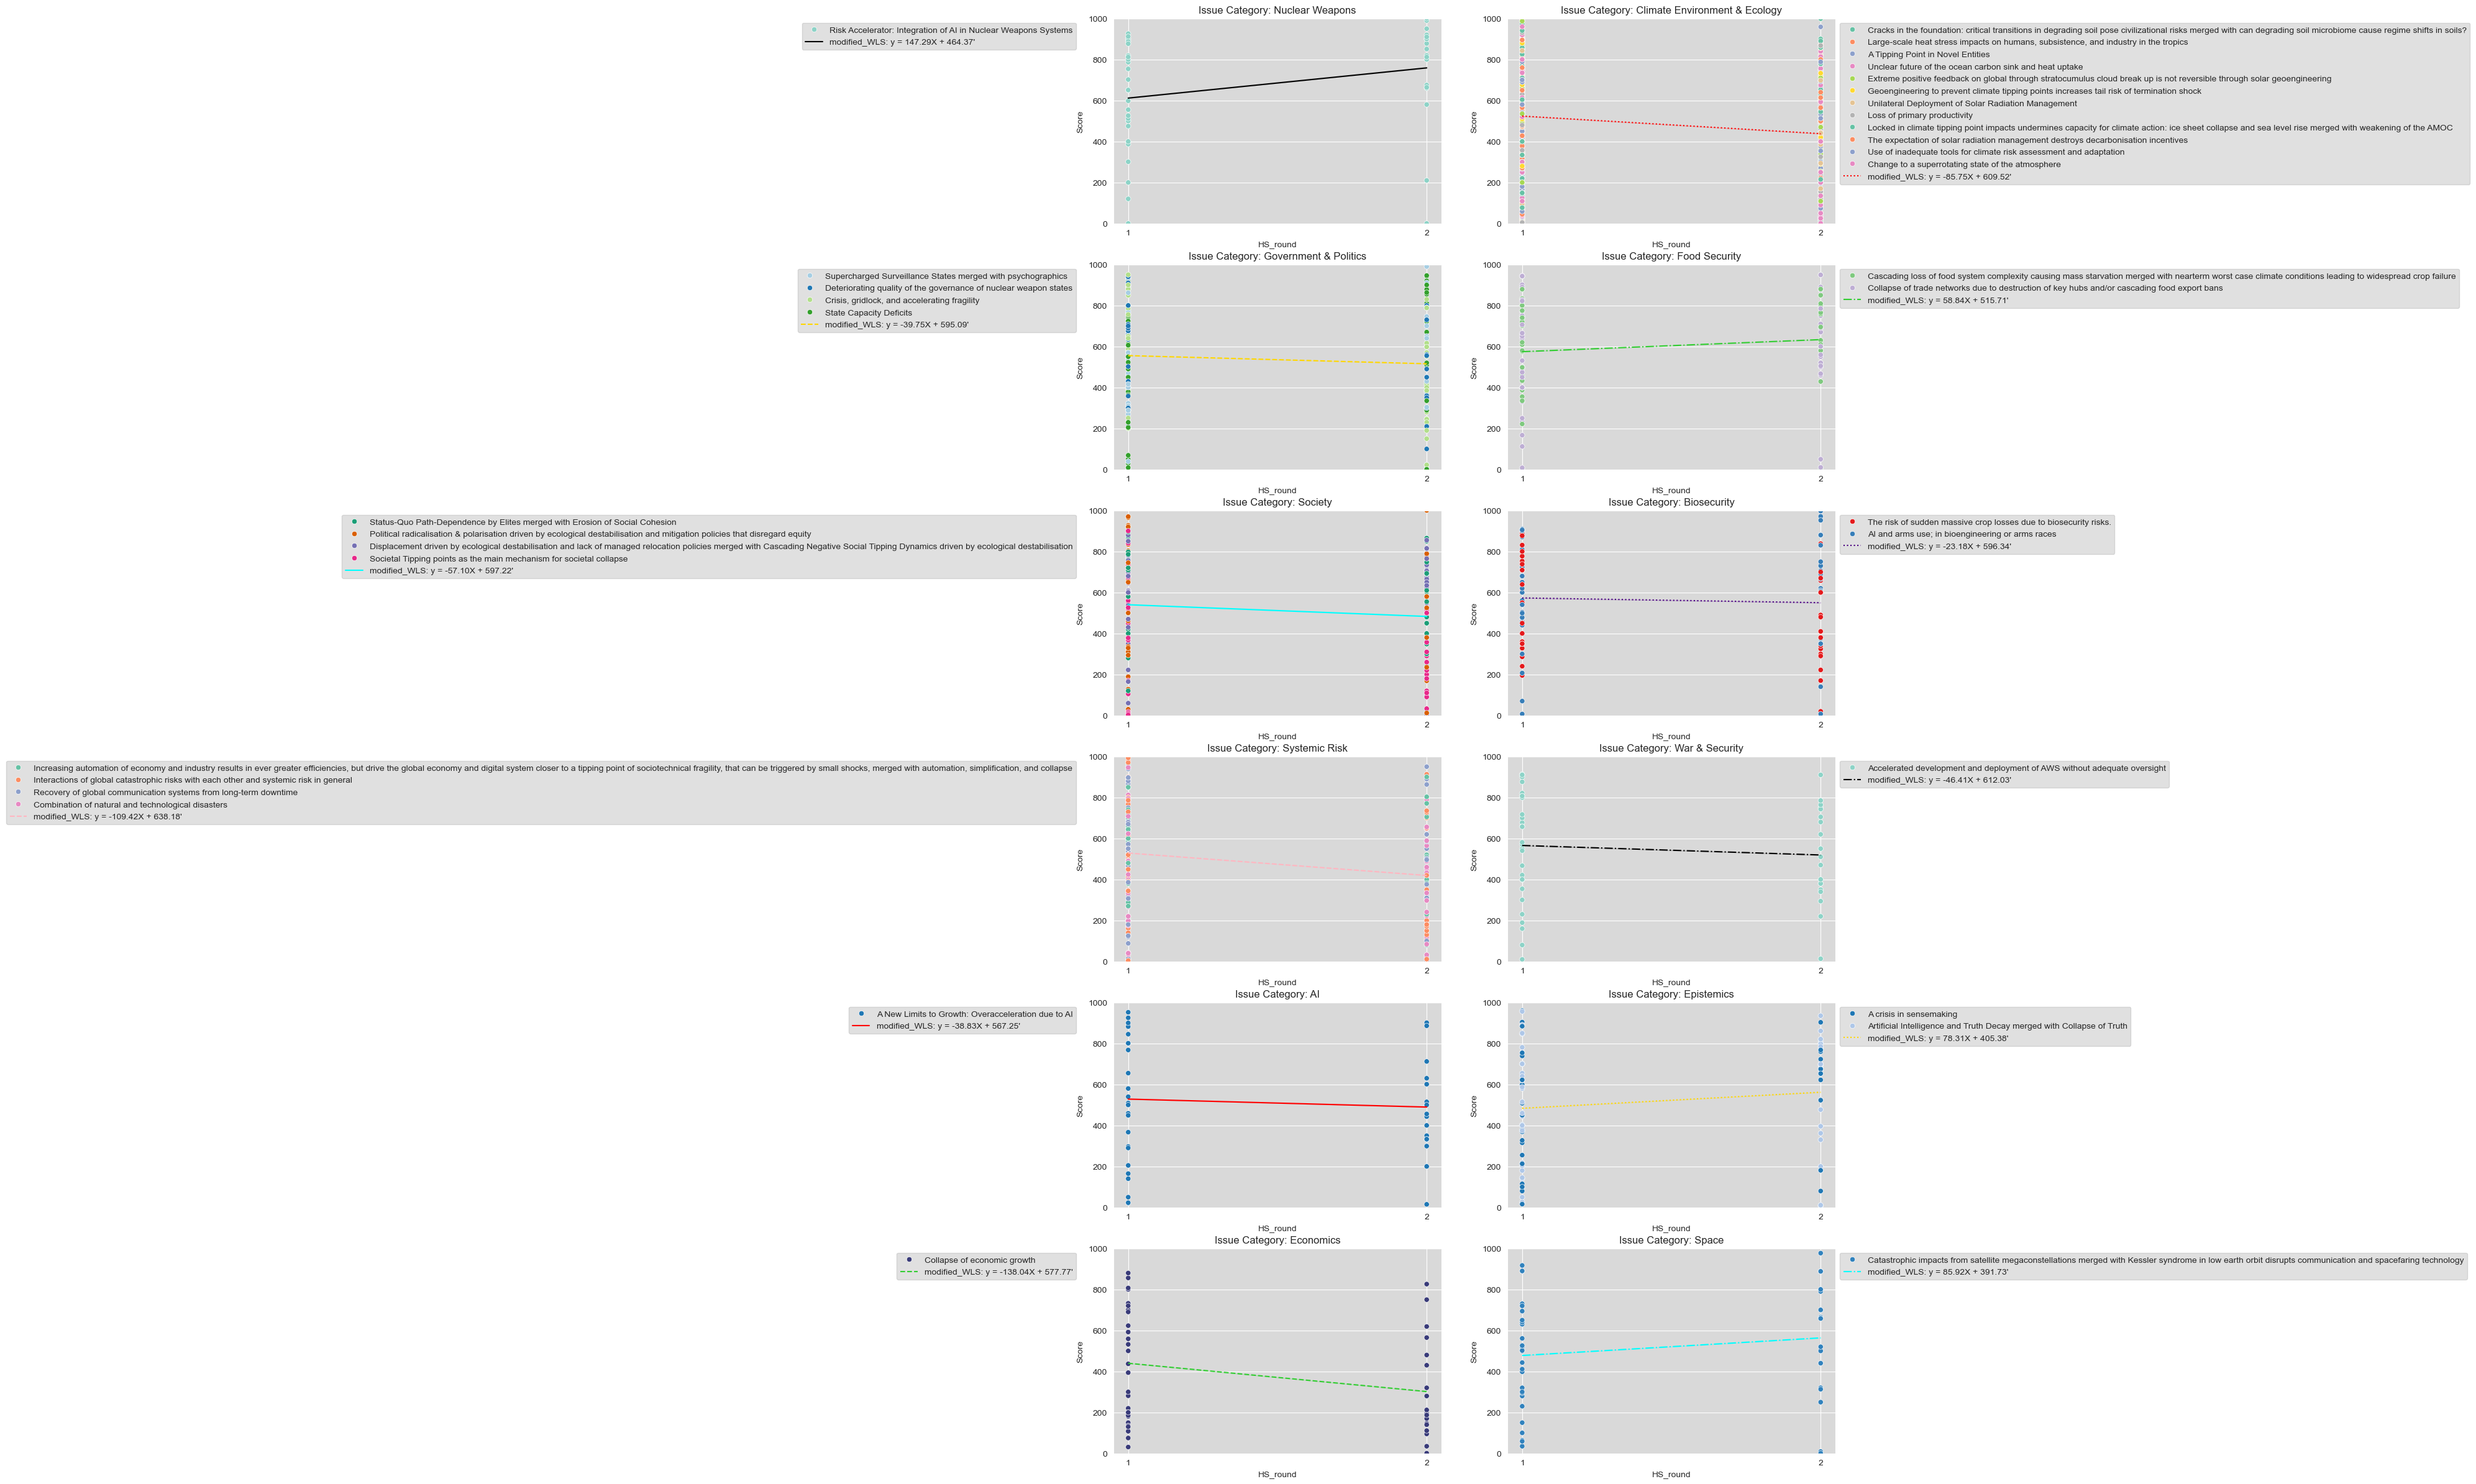

In [6]:
sns.set_style('darkgrid', {'axes.facecolor': '.85'})

fig, ax = plt.subplots(6, 2, figsize=(15, 30))

axes = ax.flatten()

r1_exp = []
r2_exp = []


for idx, cat in enumerate(justScore_Ldf['Issue_cat'].unique()):
    palette_ls = ['Set3', 'Set2', 'Paired', 'Accent', 'Dark2', 'Set1',
                  'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c']
    linestyle_ls = ['solid', 'dotted', 'dashed', 'dashdot', 'solid',
                    'dotted', 'dashed', 'dashdot', 'solid', 'dotted',
                    'dashed', 'dashdot']
    colour_ls = ['black', 'red', 'gold', 'limegreen', 'cyan', 'indigo',
                 'lightpink', 'black', 'red', 'gold', 'limegreen', 'cyan']

    justScore_cat = justScore_Ldf[justScore_Ldf['Issue_cat'] == cat]

    # Inverse WLS that uses variance as weights
    y = justScore_cat['Score']
    x = justScore_cat['HS_round']
    X_sm = sm.add_constant(x)
    variance = justScore_cat.groupby('HS_round')['Score'].var()
    in_wt = justScore_cat['HS_round'].map(variance)

    # Create model, fit, and print results
    inv_WLS = sm.WLS(y, X_sm, weights = in_wt)
    res_inv = inv_WLS.fit()
    inv_ypred = res_inv.predict()
    print("\nModified WLS results")
    print(res_inv.summary())

    # Fill DataFrame
    r1_exp.append(inv_ypred[0])
    r2_exp.append(inv_ypred[-1])
    
    splot = sns.scatterplot(justScore_cat, x='HS_round', y='Score',
                            hue='Issue', ax=axes[idx], palette=palette_ls[idx])
    WLSplot = sns.lineplot(justScore_cat, x='HS_round', y=inv_ypred,
                           ax=axes[idx], linestyle=linestyle_ls[idx], color=colour_ls[idx],
                           label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")

    axes[idx].set_title(f"Issue Category: {cat}")
    axes[idx].set_xticks([1, 2])
    axes[idx].set_ylim(1-1, 1000)

    if idx % 2 == 0:
        # Left side subplots
        axes[idx].legend(bbox_to_anchor = (-0.1, 1), ncol=1)
    else:
        # Right side subplots
        axes[idx].legend(bbox_to_anchor=(1, 1), ncol=1)

plt.tight_layout()
plt.savefig(f"{fig_output}/WLSissueCat_subplots.png")
plt.show()

# DataFrame to collect inv_WLS ypred expected values
WLS_expDF = pd.DataFrame({
    "Issue_cat": justScore_Ldf["Issue_cat"].unique(),
    "round_1": r1_exp,
    "round_2": r2_exp
})

In [7]:
justScore_Ldf['Issue_cat'].unique()

array(['Nuclear Weapons', 'Climate Environment & Ecology',
       'Government & Politics', 'Food Security', 'Society', 'Biosecurity',
       'Systemic Risk', 'War & Security', 'AI', 'Epistemics', 'Economics',
       'Space'], dtype=object)

In [8]:
WLS_expDF_L = pd.melt(WLS_expDF, id_vars="Issue_cat", value_vars=["round_1", "round_2"], var_name="HS_round", value_name="Expected_Score")

WLS_expDF_L

,Issue_cat,HS_round,Expected_Score
0,Nuclear Weapons,round_1,611.658621
1,Climate Environment & Ecology,round_1,523.775287
2,Government & Politics,round_1,555.343103
3,Food Security,round_1,574.553448
4,Society,round_1,540.122414
5,Biosecurity,round_1,573.155172
6,Systemic Risk,round_1,528.758621
7,War & Security,round_1,565.620690
8,AI,round_1,528.413793
9,Epistemics,round_1,483.689655


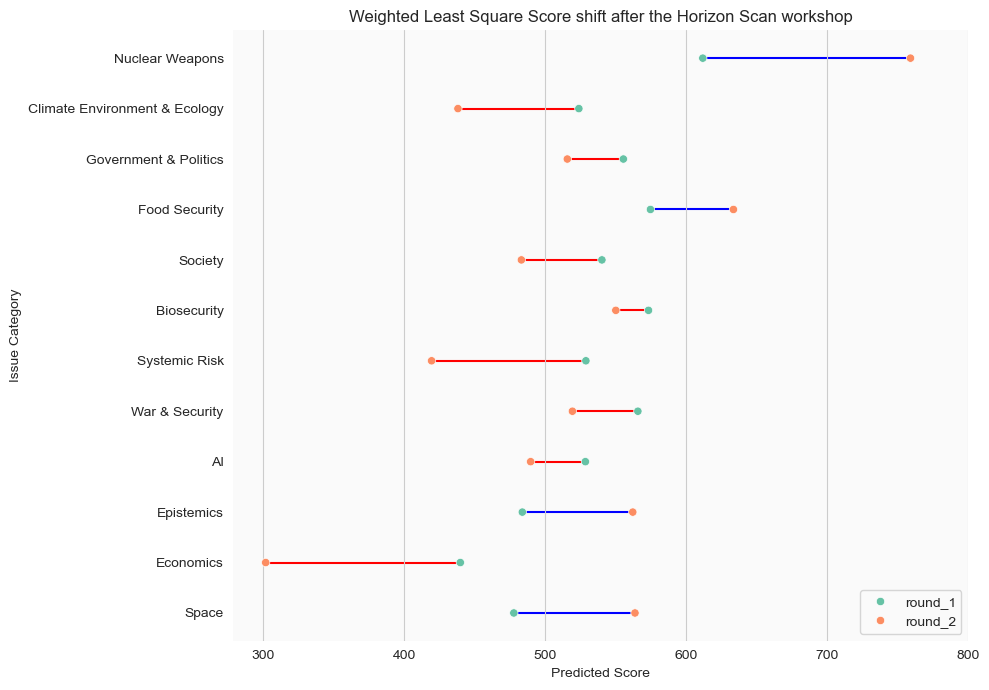

In [9]:
# Lollipop chart
sns.set_style('whitegrid', {'axes.facecolor': '0.98'})

fig, ax = plt.subplots(figsize = (10, 7))

#lolli = sns.scatterplot(WLS_expDF_L, x="Expected_Score", y="Issue_cat",
#                        hue="HS_round", palette="Set2")

for cat in WLS_expDF_L["Issue_cat"].unique():
    temp_df = WLS_expDF_L[WLS_expDF_L["Issue_cat"] == cat]

    r1_score = temp_df[temp_df["HS_round"] == "round_1"]["Expected_Score"].values[0]
    r2_score = temp_df[temp_df["HS_round"] == "round_2"]["Expected_Score"].values[0]

    if r2_score > r1_score:
        cane_col = "blue"
    else:
        cane_col = "red"        

    sns.lineplot(temp_df, x="Expected_Score", y="Issue_cat",
                 color=cane_col, zorder=0)

lolli = sns.scatterplot(WLS_expDF_L, x="Expected_Score", y="Issue_cat",
                        hue="HS_round", palette="Set2", zorder=1)


lolli.yaxis.grid(False)
lolli.legend(loc="lower right")
#lolli.set_xlim(1, 1000)
plt.xticks(list(range(300, 900, 100)))

sns.despine(left=True, bottom=True)
plt.ylabel("Issue Category")
plt.xlabel("Predicted Score")
plt.title("Weighted Least Square Score shift after the Horizon Scan workshop")

plt.tight_layout()
plt.savefig(f"{fig_output}/Deliberation_lolli.png")
plt.show()

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_4493/604860363.py:28: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  lolli = sns.scatterplot(WLS_expDF_L, x="Expected_Score", y="Issue_cat",


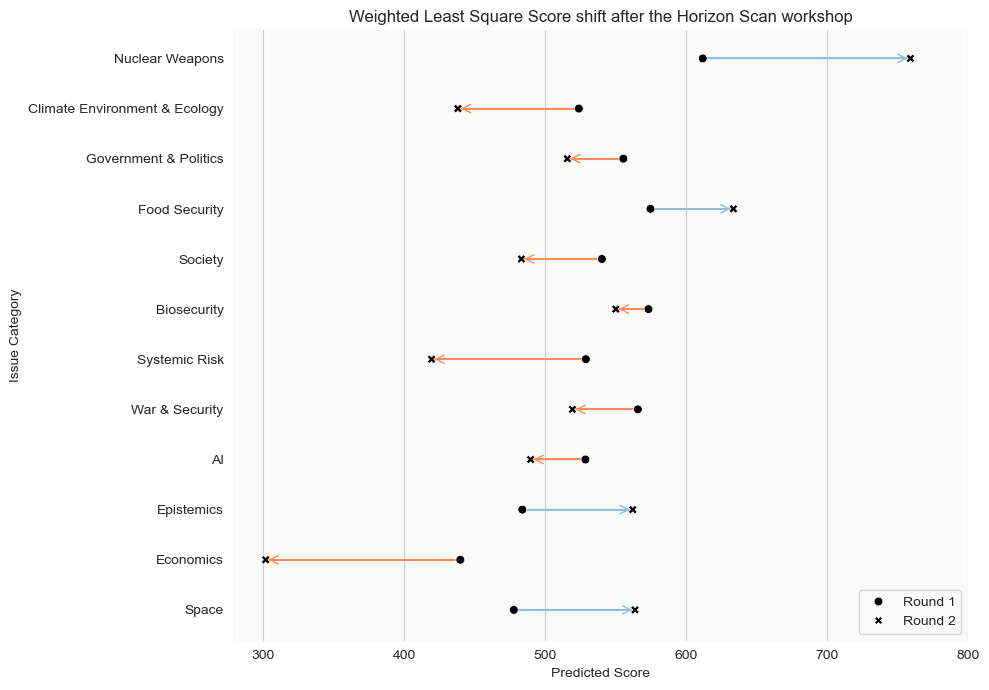

In [10]:
# Lollipop chart
sns.set_style('whitegrid', {'axes.facecolor': '0.98'})

fig, ax = plt.subplots(figsize = (10, 7))

#lolli = sns.scatterplot(WLS_expDF_L, x="Expected_Score", y="Issue_cat",
#                        hue="HS_round", palette="Set2")

for idx, cat in enumerate(WLS_expDF_L["Issue_cat"].unique()):
    temp_df = WLS_expDF_L[WLS_expDF_L["Issue_cat"] == cat]

    r1_score = temp_df[temp_df["HS_round"] == "round_1"]["Expected_Score"].values[0]
    r2_score = temp_df[temp_df["HS_round"] == "round_2"]["Expected_Score"].values[0]

    if r2_score > r1_score:
        cane_col = "#91bfdb"
        plt.gca().add_patch(FancyArrowPatch((r1_score, idx), (r2_score, idx),
                                       arrowstyle='->', color='#91bfdb', mutation_scale=15))
    else:
        cane_col = "#fc8d59"        
        plt.gca().add_patch(FancyArrowPatch((r2_score, idx), (r1_score, idx),
                                       arrowstyle='<-', color='#fc8d59', mutation_scale=15))


    sns.lineplot(temp_df, x="Expected_Score", y="Issue_cat",
                 color=cane_col, zorder=0)

lolli = sns.scatterplot(WLS_expDF_L, x="Expected_Score", y="Issue_cat",
                        color="#000000", palette="Set2", zorder=1,
                        style="HS_round", s=40)


lolli.yaxis.grid(False)
handles, _ = lolli.get_legend_handles_labels()
new_handles = ['Round 1', 'Round 2']
lolli.legend(handles, new_handles, loc="lower right")
#lolli.set_xlim(1, 1000)
plt.xticks(list(range(300, 900, 100)))

sns.despine(left=True, bottom=True)
plt.ylabel("Issue Category")
plt.xlabel("Predicted Score")
plt.title("Weighted Least Square Score shift after the Horizon Scan workshop")

plt.tight_layout()
plt.savefig(f"{fig_output}/Deliberation_lolli.png")
plt.show()